# BigBasket Capstone — Part 4: Python/Pandas Cleaning, Analysis & Cross-Validation

## Objective

This notebook independently cleans and analyzes the raw BigBasket order data using Python and Pandas.

The analysis covers:
- Raw data inspection
- Duplicate removal
- City and category cleaning
- Missing-value handling
- IQR-based outlier detection and capping
- Date and derived-column creation
- Category revenue analysis
- Supplier revenue analysis
- Cross-validation with Part 1 SQL findings
- Business visualizations
- Three What / Why / Next Step observations











In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
ORDERS_PATH = "/content/drive/MyDrive/BigBasket_Capstone/orders_raw.csv"
PRODUCTS_PATH = "/content/drive/MyDrive/BigBasket_Capstone/products.csv"

df = pd.read_csv(ORDERS_PATH)
products = pd.read_csv(PRODUCTS_PATH)

print("Orders shape:", df.shape)
print("Products shape:", products.shape)

Orders shape: (508, 11)
Products shape: (31, 5)


In [5]:
print("========== DATA INFO ==========")
df.info()

print("\n========== DESCRIPTIVE STATISTICS ==========")
display(df.describe(include="all"))

print("\n========== STATUS COUNTS ==========")
print(df["status"].value_counts(dropna=False))

========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

========== DESCRIPTIVE STATISTICS ==========


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000



========== STATUS COUNTS ==========
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


## What looks wrong in the raw data?

The raw orders file contains more than 500 rows, indicating that duplicate order records are present.

The `city` and `category` columns contain inconsistent casing and/or whitespace, so values representing the same city or category may appear as different strings.

Some `amount_inr` values are missing and must not be treated as zero because the actual revenue amount is unknown.

Some `amount_inr` values are unusually large compared with the normal order amounts, so they need to be investigated using an IQR-based outlier check.

The `rating` field can be null for Cancelled and Pending orders because only Delivered orders receive ratings. These null ratings are therefore legitimate and will be left unchanged.

In [6]:
before_rows = len(df)

duplicate_rows = df.duplicated(subset="order_id").sum()

df = df.drop_duplicates(subset="order_id", keep="first").copy()

after_rows = len(df)

print("Rows before deduplication:", before_rows)
print("Duplicate order_id rows removed:", duplicate_rows)
print("Rows after deduplication:", after_rows)

assert after_rows == 500

Rows before deduplication: 508
Duplicate order_id rows removed: 8
Rows after deduplication: 500


In [7]:
df["city"] = df["city"].astype("string").str.strip().str.title()
df["category"] = df["category"].astype("string").str.strip().str.title()

cities = sorted(df["city"].dropna().unique())
categories = sorted(df["category"].dropna().unique())

print("Distinct cities:")
print(cities)

print("\nNumber of cities:", len(cities))

print("\nDistinct categories:")
print(categories)

print("\nNumber of categories:", len(categories))

assert df["city"].nunique() == 4
assert df["category"].nunique() == 6

Distinct cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Number of cities: 4

Distinct categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Number of categories: 6


In [9]:
# Convert amount_inr to numeric
df["amount_inr"] = pd.to_numeric(df["amount_inr"], errors="coerce")

# Count missing revenue values
missing_amount = df["amount_inr"].isna().sum()

print("Missing amount_inr rows:", missing_amount)

# Check rating nulls for Cancelled and Pending orders
cancelled_pending = df["status"].isin(["Cancelled", "Pending"])

print(
    "Cancelled/Pending rows with null rating:",
    df.loc[cancelled_pending, "rating"].isna().sum()
)

print(
    "Total Cancelled/Pending orders:",
    cancelled_pending.sum()
)

Missing amount_inr rows: 10
Cancelled/Pending rows with null rating: 66
Total Cancelled/Pending orders: 66


## Missing-Value Business Logic

There are 10 missing values in `amount_inr`. These rows will be excluded from all revenue calculations because a missing revenue amount is unknown and should not be treated as zero or replaced with an average.

Rating values are legitimately null for all 66 Cancelled and Pending orders because only Delivered orders receive ratings. These null ratings are therefore left unchanged and are not treated as a data-quality problem.

In [10]:
delivered_amount = df.loc[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna()),
    "amount_inr"
]

q1 = delivered_amount.quantile(0.25)
q3 = delivered_amount.quantile(0.75)

iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outlier_mask = (
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna()) &
    (df["amount_inr"] > upper_fence)
)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper fence:", upper_fence)
print("Rows above upper fence:", outlier_mask.sum())

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5
Rows above upper fence: 16


In [11]:
# Create a capped revenue column
df["amount_capped"] = df["amount_inr"]

# Cap only Delivered orders at the upper fence
delivered_mask = df["status"] == "Delivered"

df.loc[delivered_mask, "amount_capped"] = (
    df.loc[delivered_mask, "amount_inr"]
    .clip(upper=upper_fence)
)

print("Upper fence:", upper_fence)
print("Number of rows capped:", outlier_mask.sum())

Upper fence: 552.5
Number of rows capped: 16


## Outlier Capping

For Delivered orders with non-null revenue, the IQR method produced an upper fence of 552.5. There are 16 values above this fence.

These values were capped using `.clip(upper=552.5)` rather than being removed. This preserves the orders while limiting the effect of unusually large values on revenue analysis.

In [12]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

# Revenue per unit uses the capped amount
df["revenue_per_unit"] = df["amount_capped"] / df["quantity"]

df["is_delivered"] = df["status"].eq("Delivered")

display(df.head())

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,amount_capped,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,175.0,3,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,60.0,5,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,150.0,6,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,30.0,3,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,220.0,4,April,110.0,True


In [15]:
delivered = df.loc[
    df["is_delivered"] &
    df["amount_capped"].notna()
].copy()

print("Delivered rows with non-null capped revenue:", len(delivered))

Delivered rows with non-null capped revenue: 425


In [16]:
# STEP 7A — Delivered revenue by category

category_revenue = (
    delivered
    .groupby("category", as_index=False)["amount_capped"]
    .sum()
    .sort_values("amount_capped", ascending=False)
)

print("Delivered revenue by category:")
display(category_revenue)

top_category = category_revenue.iloc[0]["category"]
top_category_revenue = category_revenue.iloc[0]["amount_capped"]

print("Top category:", top_category)
print("Top category revenue:", top_category_revenue)

assert top_category == "Household Essentials"

Delivered revenue by category:


,category,amount_capped
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


Top category: Household Essentials
Top category revenue: 20910.0


In [24]:
# STEP 7B — Merge orders with products to bring supplier information

merged = pd.merge(
    delivered,
    products[["product_id", "supplier"]],
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Merged data:")
display(merged.head())

print("Missing supplier values:", merged["supplier"].isna().sum())

supplier_revenue = (
    merged
    .groupby("supplier", as_index=False)["amount_capped"]
    .sum()
    .sort_values("amount_capped", ascending=False)
)

print("Delivered revenue by supplier:")
display(supplier_revenue)

top_supplier = supplier_revenue.iloc[0]["supplier"]
top_supplier_revenue = supplier_revenue.iloc[0]["amount_capped"]

print("Top supplier:", top_supplier)
print("Top supplier revenue:", top_supplier_revenue)

assert top_supplier == "HomeEssentials Traders"

Merged data:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,amount_capped,month,month_name,revenue_per_unit,is_delivered,supplier
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,175.0,3,March,35.0,True,BakeHouse Supplies
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,60.0,5,May,60.0,True,BakeHouse Supplies
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,150.0,6,June,75.0,True,HomeEssentials Traders
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,30.0,3,March,30.0,True,SnackHub India
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,220.0,4,April,110.0,True,SnackHub India


Missing supplier values: 0
Delivered revenue by supplier:


,supplier,amount_capped
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5
4,FreshFarms Co,5490.0
5,GreenValley Traders,3680.0
2,CountryEggs Farms,2965.0


Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0


### Cross-validation with Part 1

The independently cleaned Pandas analysis identifies **Household Essentials** as the top category by delivered revenue and **HomeEssentials Traders** as the top supplier by delivered revenue.

These findings match the Part 1 SQL diagnostic. The exact revenue amounts differ because Part 4 starts from the raw, messy data and applies deduplication, missing-value exclusion, and IQR-based outlier capping, while Part 1 uses the clean database data.

In [18]:
# STEP 8 — Monthly delivered revenue

monthly_revenue = (
    delivered
    .groupby(["month", "month_name"], as_index=False)["amount_capped"]
    .sum()
    .sort_values("month")
)

print("Monthly delivered revenue:")
display(monthly_revenue)

peak_month = monthly_revenue.loc[
    monthly_revenue["amount_capped"].idxmax(),
    "month_name"
]

peak_month_revenue = monthly_revenue["amount_capped"].max()

print("Peak revenue month:", peak_month)
print("Peak month revenue:", peak_month_revenue)

Monthly delivered revenue:


,month,month_name,amount_capped
0,1,January,10059.5
1,2,February,13715.0
2,3,March,14747.5
3,4,April,16558.5
4,5,May,16668.5
5,6,June,12888.0


Peak revenue month: May
Peak month revenue: 16668.5


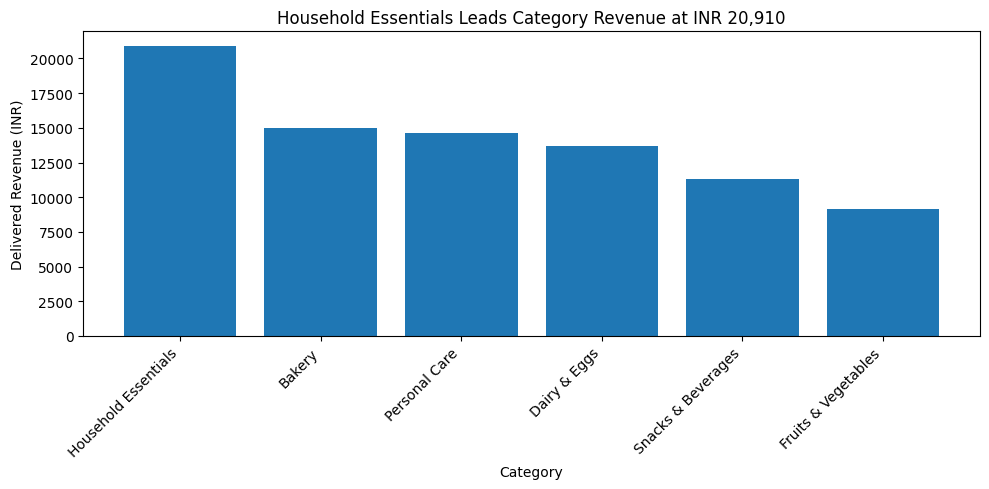

In [19]:
# Chart 1 — Category revenue

plt.figure(figsize=(10, 5))

plt.bar(
    category_revenue["category"],
    category_revenue["amount_capped"]
)

plt.title(
    f"Household Essentials Leads Category Revenue at INR {top_category_revenue:,.0f}"
)

plt.xlabel("Category")
plt.ylabel("Delivered Revenue (INR)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

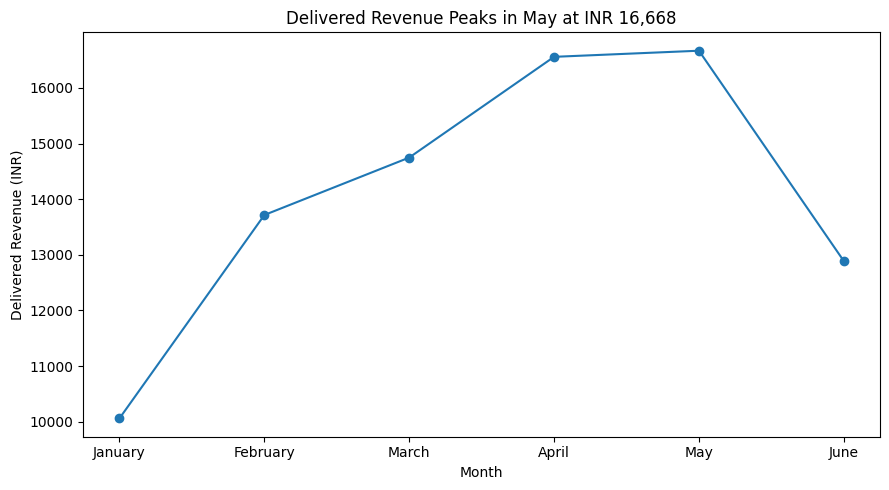

In [20]:
# Chart 2 — Monthly delivered revenue trend

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_revenue["month_name"],
    monthly_revenue["amount_capped"],
    marker="o"
)

plt.title(
    f"Delivered Revenue Peaks in {peak_month} at INR {peak_month_revenue:,.0f}"
)

plt.xlabel("Month")
plt.ylabel("Delivered Revenue (INR)")

plt.tight_layout()
plt.show()

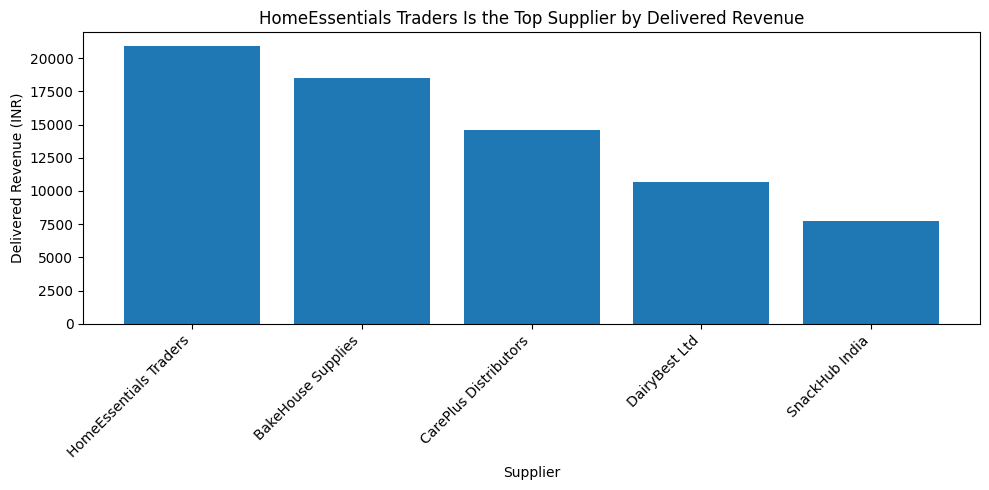

In [21]:
# Chart 3 — Top 5 supplier revenue

top5_suppliers = supplier_revenue.head(5)

plt.figure(figsize=(10, 5))

plt.bar(
    top5_suppliers["supplier"],
    top5_suppliers["amount_capped"]
)

plt.title(
    f"{top_supplier} Is the Top Supplier by Delivered Revenue"
)

plt.xlabel("Supplier")
plt.ylabel("Delivered Revenue (INR)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
# Category shortfall analysis

category_targets = {
    "Fruits & Vegetables": 12000,
    "Dairy & Eggs": 16500,
    "Snacks & Beverages": 13000,
    "Personal Care": 15500,
    "Household Essentials": 17000,
    "Bakery": 12000
}

category_revenue["target_revenue"] = category_revenue["category"].map(category_targets)

category_revenue["variance"] = (
    category_revenue["target_revenue"] - category_revenue["amount_capped"]
)

category_revenue["status"] = category_revenue["variance"].apply(
    lambda x: "Below Target" if x > 0 else "At/Above Target"
)

display(category_revenue)

,category,amount_capped,target_revenue,variance,status
3,Household Essentials,20910.0,17000,-3910.0,At/Above Target
0,Bakery,14975.0,12000,-2975.0,At/Above Target
4,Personal Care,14594.5,15500,905.5,Below Target
1,Dairy & Eggs,13675.0,16500,2825.0,Below Target
5,Snacks & Beverages,11312.5,13000,1687.5,Below Target
2,Fruits & Vegetables,9170.0,12000,2830.0,Below Target


In [23]:
# Find the category with the largest revenue shortfall

below_target = category_revenue[
    category_revenue["status"] == "Below Target"
].copy()

largest_shortfall = below_target.loc[
    below_target["variance"].idxmax()
]

print("Category with largest shortfall:", largest_shortfall["category"])
print("Shortfall amount (INR):", round(largest_shortfall["variance"], 2))

Category with largest shortfall: Fruits & Vegetables
Shortfall amount (INR): 2830.0


## Three Business Insights

### 1. Category performance

**What:** Household Essentials is the highest-revenue category, generating INR 20,910 in delivered capped revenue.

**Why it matters:** It is the strongest category in the cleaned analysis and is therefore an important contributor to overall revenue.

**Next step:** Prioritize assortment and promotional activity for Household Essentials while monitoring whether its strong performance continues.

### 2. Category shortfall

**What:** Fruits & Vegetables generates INR 9,170 in delivered capped revenue, which is INR 2,830 below its INR 12,000 target.

**Why it matters:** It has the largest revenue shortfall among the six categories in the cleaned analysis.

**Next step:** Review this category's product mix and promotional performance to identify actions that could improve revenue.

### 3. Monthly performance

**What:** Delivered revenue peaks in May at INR 16,668.

**Why it matters:** The monthly trend shows when revenue was strongest during the six-month period.

**Next step:** Compare the peak month's category performance with weaker months to identify which categories contributed to the increase.

In [26]:
# Explicit cross-validation with Part 1 SQL findings

part1_top_category = "Household Essentials"
part1_top_supplier = "HomeEssentials Traders"

print("Part 4 top category:", top_category)
print("Part 1 top category:", part1_top_category)
print("Category match:", top_category == part1_top_category)

print("Part 4 top supplier:", top_supplier)
print("Part 1 top supplier:", part1_top_supplier)
print("Supplier match:", top_supplier == part1_top_supplier)

assert top_category == part1_top_category
assert top_supplier == part1_top_supplier

Part 4 top category: Household Essentials
Part 1 top category: Household Essentials
Category match: True
Part 4 top supplier: HomeEssentials Traders
Part 1 top supplier: HomeEssentials Traders
Supplier match: True


# AI Log

## Prompt 1 — Part 1
## Prompt 1 — Part 1 SQL Analysis

### Role
You are a senior SQL and retail data analyst helping me complete a BigBasket category revenue diagnostic.

### Context
I am working with a BigBasket dataset containing products, customers, orders, and category targets. The objective is to build SQL queries that verify the database, analyze delivered revenue by category, and produce a monthly category revenue output for use in Google Sheets and Tableau.

### Task
Help me write and verify SQL queries for database validation, foundational SELECT/WHERE/DISTINCT/ORDER BY queries, aggregation and joins, and the final monthly delivered revenue by category. The analysis should identify the top-performing category and compare category revenue with the target revenue.

### Constraints
1. Use SQLite-compatible SQL.
2. Count products, customers, orders, and category targets.
3. Check order status counts.
4. Revenue calculations should use Delivered orders.
5. Join orders with products where category or supplier information is required.
6. Produce monthly revenue by category.
7. Keep the SQL outputs reproducible and suitable for export to CSV.

### Format
Provide the SQL queries with clear labels and explain what each query verifies.

### Verification performed
I verified that the database contains 30 products, 50 customers, 500 orders, and 6 category targets. The Part 1 analysis identified Household Essentials as the top category by delivered revenue and HomeEssentials Traders as the top supplier.

## Prompt 2 — Part 4 Pandas Cleaning and Analysis

### Role
You are a senior Python and Pandas data-analysis reviewer.

### Context
I am cleaning a raw BigBasket orders dataset in a Jupyter notebook. The data contains duplicate order IDs, missing amount_inr values, suspiciously large delivered-order amounts, inconsistent casing and whitespace in city/category, and legitimate null ratings for Cancelled and Pending orders.

### Task
Review and help debug my Pandas cleaning and IQR outlier-handling logic. I need to calculate Q1 and Q3 only on Delivered orders with non-null amount_inr, calculate the upper IQR fence, and cap values above the fence instead of dropping them. I also need to merge the cleaned orders with products.csv using product_id to analyze supplier revenue.

### Constraints
1. Deduplicate using order_id and keep the first occurrence.
2. Do not fill missing amount_inr values with zero or an average.
3. Do not fill rating values for Cancelled or Pending orders.
4. Calculate the IQR only on Delivered, non-null amount_inr values.
5. Cap outliers using .clip(upper=upper_fence), not by dropping them.
6. Use pd.merge() on product_id to bring supplier into the cleaned dataset.
7. The top category and top supplier should be cross-validated against Part 1.

### Format
Explain the logic, provide corrected Pandas code where necessary, and provide concrete checks that I can run to verify the result.

### Verification performed
I reran the IQR calculation and confirmed Q1 = 90, Q3 = 275, IQR = 185, and the upper fence = 552.5. I also confirmed that 16 Delivered rows were above the upper fence before capping. After applying .clip(upper=552.5), the affected values were capped at exactly 552.5 rather than being removed. I reran the supplier merge and confirmed that HomeEssentials Traders remained the top supplier.